### Imports

In [3]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
from contextlib import redirect_stderr
import io
import os
import numpy as np
import tqdm
from collections import defaultdict

_f = io.StringIO()
with redirect_stderr(_f):
    import evaluate

## Automated Evaluation Metrics

### Figure 3 (Constants)

In [4]:
FIGURE_3_MODELS = [
  "mistral",
  "llama",
  "qwen",
  "deepseek_llama",
  "deepseek_qwen",
  "biomistral",
  "meditron",
  "gpt4o",
  "gpt4o_mini",
  "claude3_5",
  "o1",
  "o1_mini",
  "referring_physician"
]

FIGURE_3_DISPLAY_NAMES = [
    'Mistral\nv0.3', 
    'Llama 3.1', 
    "Qwen 2.5",
    'DeepSeek\nLlama',
    'DeepSeek\nQwen',
    'BioMistral', 
    'Meditron3', 
    'GPT-4o', 
    'GPT-4o\nmini',
    "Claude 3.5\nSonnet",
    "o1",
    "o1 mini",
    "Referring\nClinician"
]

### Figure 3 (Code)

In [52]:
def fig3_plot_data(ax, metric, model_data, models, display_names, legend=False):
    all_values = []
    all_labels = []

    for model, name in zip(models, display_names):
        scores = model_data[model][metric]
        all_values.extend(scores)
        all_labels.extend([name] * len(scores))

    df_plot = pd.DataFrame({
        "Model": all_labels,
        "Score": all_values
    })

    order = display_names
    colors = [
        '#F7414D', '#F7414D', '#F7414D', # Open-Source (General-Purpose) - BRIGHT RED
        '#F5963D', '#F5963D',            # Open-Source (Reasoning)
        '#F8B1FC', '#F8B1FC',            # Open-Source (Medical Domain)
        '#0496FF', '#0496FF', '#0496FF', # Proprietary (General-Purpose) - BRIGHT BLUE
        '#BC81DA', '#BC81DA',            # Proprietary (Reasoning)
        '#FFD639'                        # Referring Clinician - YELLOW
    ]

    sns.violinplot(
        data=df_plot,
        x='Model',
        y='Score',
        order=order,
        ax=ax,
        inner=None,
        linewidth=0,
        width=0.75,
        palette=colors,
        alpha=0.4, 
        cut=0,
        zorder=1
    )

    for i, name in enumerate(order):
        scores = df_plot[df_plot["Model"] == name]["Score"].values
        if len(scores) > 0:
            ax.boxplot(
                scores,
                positions=[i],
                widths=0.12, 
                patch_artist=True,
                showfliers=True,
                manage_ticks=False,
                boxprops=dict(facecolor=colors[i], edgecolor="#333333", linewidth=1.75, alpha=0.9, zorder=3),
                medianprops=dict(color="black", linewidth=1.75, zorder=4),
                whiskerprops=dict(color="#333333", linewidth=1.75, zorder=3),
                capprops=dict(color="#333333", linewidth=1.75, zorder=3),
                flierprops=dict(marker='o', markersize=2, alpha=0.2, 
                                markerfacecolor='black', markeredgecolor='none', zorder=2)
            )

    ax.set_xticks(np.arange(len(order)))
    ax.set_xticklabels(order)                 
    ax.tick_params(axis='x', length=0)        
    ax.tick_params(axis='x', labelbottom=True)  

    path = 'fonts/HelveticaNeue.ttf'
    try:
        fontprop = fm.FontProperties(fname=path, size=14)
        label_font = fm.FontProperties(fname=path, size=18)
    except:
        fontprop = fm.FontProperties(size=14)
        label_font = fm.FontProperties(size=18)

    ax.set_ylabel(metric.upper(), labelpad=20, fontproperties=label_font)
    ax.set_xlabel("")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if metric == "bertscore":
        ax.set_ylim(-100, 100)
    else:
        ax.set_ylim(0, 100)

    for label in ax.get_yticklabels():
        label.set_fontproperties(fontprop)
    for label in ax.get_xticklabels():
        label.set_fontproperties(fontprop)
        label.set_rotation(0)
        label.set_ha('center')

    if legend:
        handles = [
            mpatches.Patch(color='#F7414D', label='Open-Source (General-Purpose)'),
            mpatches.Patch(color='#F5963D', label='Open-Source (Reasoning)'),
            mpatches.Patch(color='#F8B1FC', label='Open-Source (Medical Domain)'),
            mpatches.Patch(color='#0496FF', label='Proprietary (General-Purpose)'),
            mpatches.Patch(color='#BC81DA', label='Proprietary (Reasoning)'),
            mpatches.Patch(color='#FFD639', label='Referring Clinician')
        ]
        ax.legend(
            handles=handles,
            prop=fontprop,
            loc='upper center',
            ncols=3,
            frameon=False,
            bbox_to_anchor=(0.5, 1.2)
        )

### Figure 3 (Graphic)

100%|███████████████████████████████████████████| 13/13 [00:00<00:00, 25.05it/s]


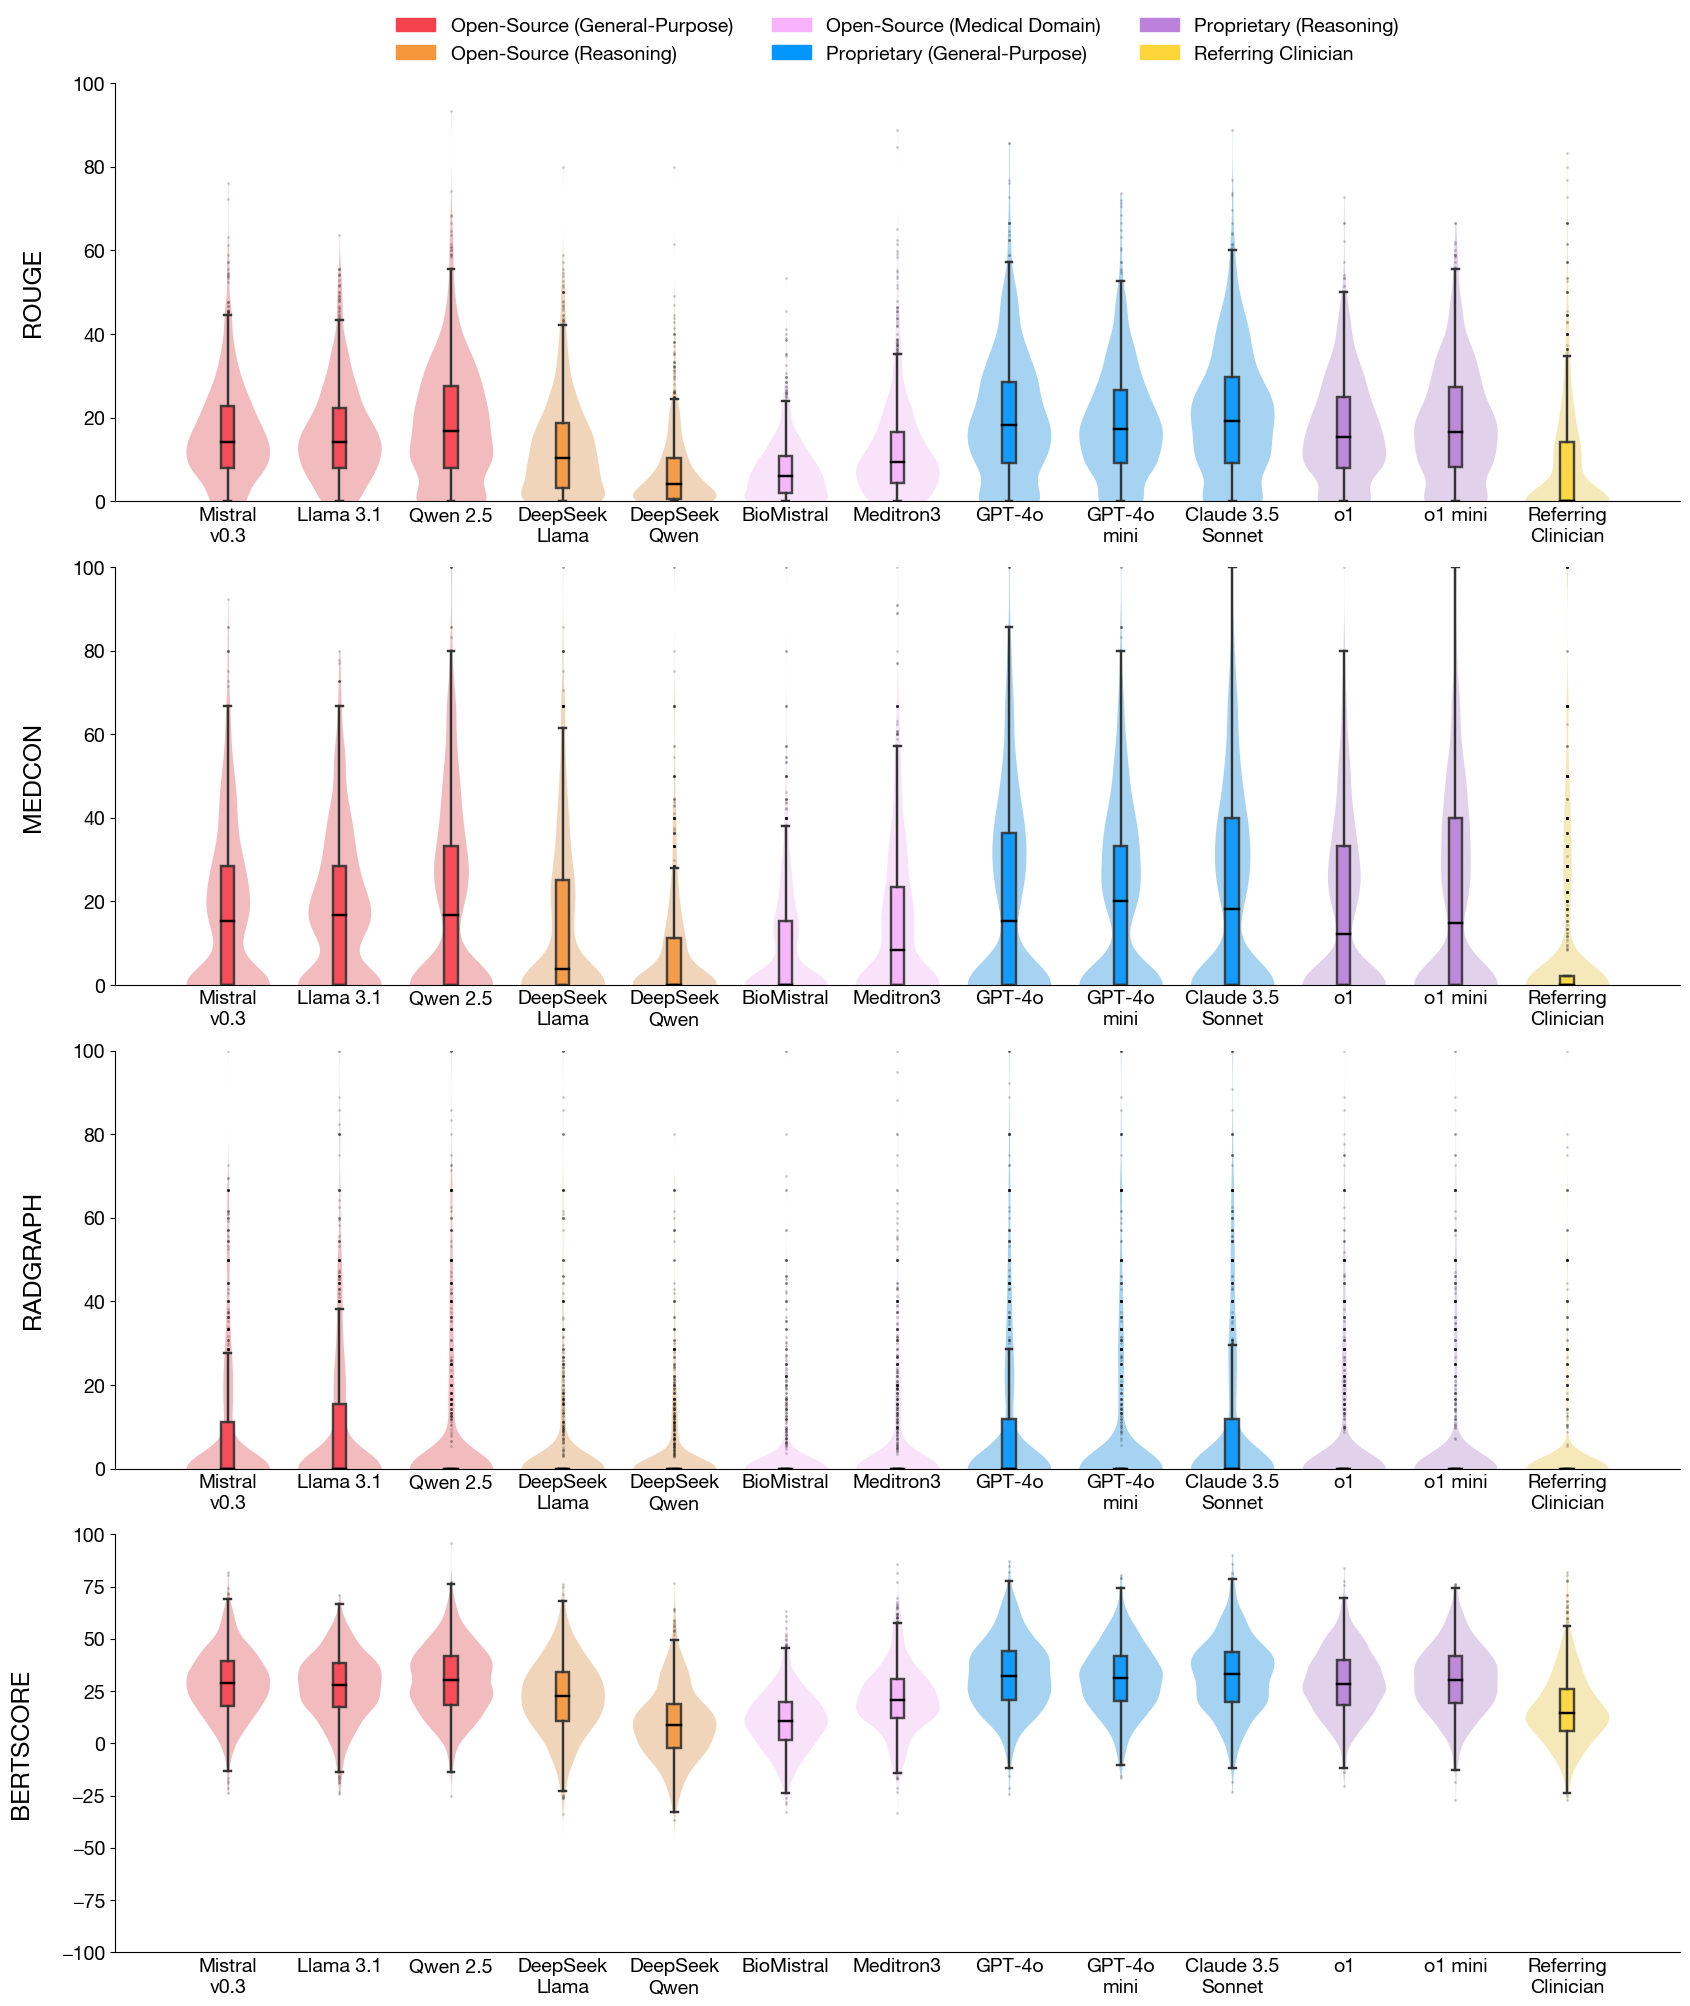

In [53]:
fig3_model_data = {}
metrics = ["rouge", "medcon", "radgraph", "bertscore"]

for model in tqdm.tqdm(FIGURE_3_MODELS):
    model_scores = pd.read_csv(f"../analysis/llm_evaluation_scores/{model}.csv")
    model_info = {}
    for metric in metrics:
        # Maintaining your percentage scaling
        model_info[metric] = np.array(model_scores[metric].tolist()) * 100 
    fig3_model_data[model] = model_info

fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(17, 20), sharex=True)

for i, metric in enumerate(metrics):
    fig3_plot_data(ax[i], metric, fig3_model_data, FIGURE_3_MODELS, FIGURE_3_DISPLAY_NAMES, legend=(i==0))

plt.tight_layout()
plt.savefig("figures/fig3_violin_box.png", dpi=300)
plt.show()

### Figure 4 (Constants)

In [21]:
MODELS = ["qwen", "claude3_5", "referring_physician"]
DISPLAY_NAMES = {
    "qwen": "Best open-source LLM (Qwen 2.5-7B Instruct)",
    "claude3_5": "Best proprietary LLM (Claude 3.5 Sonnet)",
    "referring_physician": "Referring Clinician",
}
DISPLAY_LABELS = {
    "body_system": ["Brain", "Head/Neck", "Chest", "Abdomen/\nPelvis", "MSK"],
    "pathophysiological_category": ["Cancer/\nMass", "Symptom-based", "Surgical", "Infection/\nInflammatory", "Structural"],
}
HUE_ORDER = [DISPLAY_NAMES[m] for m in MODELS]
PALETTE = {
    HUE_ORDER[0]: "#F7414D", # Qwen (Red)
    HUE_ORDER[1]: "#0496FF", # Claude (Blue)
    HUE_ORDER[2]: "#FFD639", # Human (Yellow)
}

BODY_MAP = {"Head": "Brain", "Neck": "Head/Neck", "Abdomen/Pelvis": "Abdomen/\nPelvis"}
PATHO_MAP = {"Infection/Inflammatory": "Infection/\nInflammatory", "Cancer/Mass": "Cancer/\nMass"}

### Figure 4 (Code)

In [50]:
def fig4_plot_data(df_main, font_path='fonts/HelveticaNeue.ttf'):
    f_reg = fm.FontProperties(fname=font_path, size=12)
    f_bold = fm.FontProperties(fname=font_path, size=13, weight='bold')
    f_title = fm.FontProperties(fname=font_path, size=16, weight='bold')

    fig, axes = plt.subplots(4, 2, figsize=(16, 18))
    metrics = ["rouge", "medcon", "radgraph", "bertscore"]

    for row, metric in enumerate(metrics):
        for col, g_key in enumerate(DISPLAY_LABELS.keys()):
            ax = axes[row, col]
            x_order = DISPLAY_LABELS[g_key]
            
            df_plot = df_main[[g_key, metric, "Model"]].copy().rename(columns={g_key: "Label", metric: "Score"})
            df_plot = df_plot.dropna(subset=["Score"])
            df_plot["Score"] = pd.to_numeric(df_plot["Score"]) * 100.0

            sns.violinplot(
                data=df_plot, x="Label", y="Score", hue="Model",
                order=x_order, hue_order=HUE_ORDER, palette=PALETTE,
                ax=ax, inner=None, dodge=True, width=0.8, linewidth=0, alpha=0.4, cut=0
            )

            total_width = 0.8
            n_models = len(HUE_ORDER)
            offsets = np.linspace(0, total_width - (total_width/n_models), n_models) - (total_width - (total_width/n_models)) / 2
            
            for i, model_name in enumerate(HUE_ORDER):
                valid_pos, valid_data = [], []
                for j, label in enumerate(x_order):
                    scores = df_plot[(df_plot["Model"] == model_name) & (df_plot["Label"] == label)]["Score"].values
                    if scores.size > 0:
                        valid_pos.append(j + offsets[i])
                        valid_data.append(scores)
                
                if valid_data:
                    ax.boxplot(valid_data, positions=valid_pos, widths=0.12, patch_artist=True, 
                               showfliers=True, manage_ticks=False,
                               boxprops=dict(facecolor=PALETTE[model_name], edgecolor="#333333", linewidth=1.25, alpha=0.9, zorder=3),
                               medianprops=dict(color="black", linewidth=1.25, zorder=4),
                               whiskerprops=dict(color="#333333", linewidth=1.25, zorder=3),
                               capprops=dict(color="#333333", linewidth=1.25, zorder=3),
                               flierprops=dict(marker='o', markersize=2, alpha=0.2, 
                               markerfacecolor='black', markeredgecolor='none', zorder=2)
                              )

            ax.set_xticks(range(len(x_order)))
            ax.set_xticklabels(x_order, fontproperties=f_reg)
            ax.set_ylabel(metric.upper(), fontproperties=f_bold)
            ax.set_xlabel("")
            ax.set_ylim(-100, 100) if metric == "bertscore" else ax.set_ylim(0, 105)
            
            if row == 0:
                ax.set_title("Body Systems" if col == 0 else "Pathophysiological Categories", fontproperties=f_title, pad=20)
            
            if ax.get_legend(): ax.get_legend().remove()
            sns.despine(ax=ax)

    legend_handles = [mpatches.Patch(color=PALETTE[name], label=name) for name in HUE_ORDER]
    leg = fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.98))
    for text in leg.get_texts():
        text.set_fontproperties(f_reg)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

### Figure 4 (Graphic)

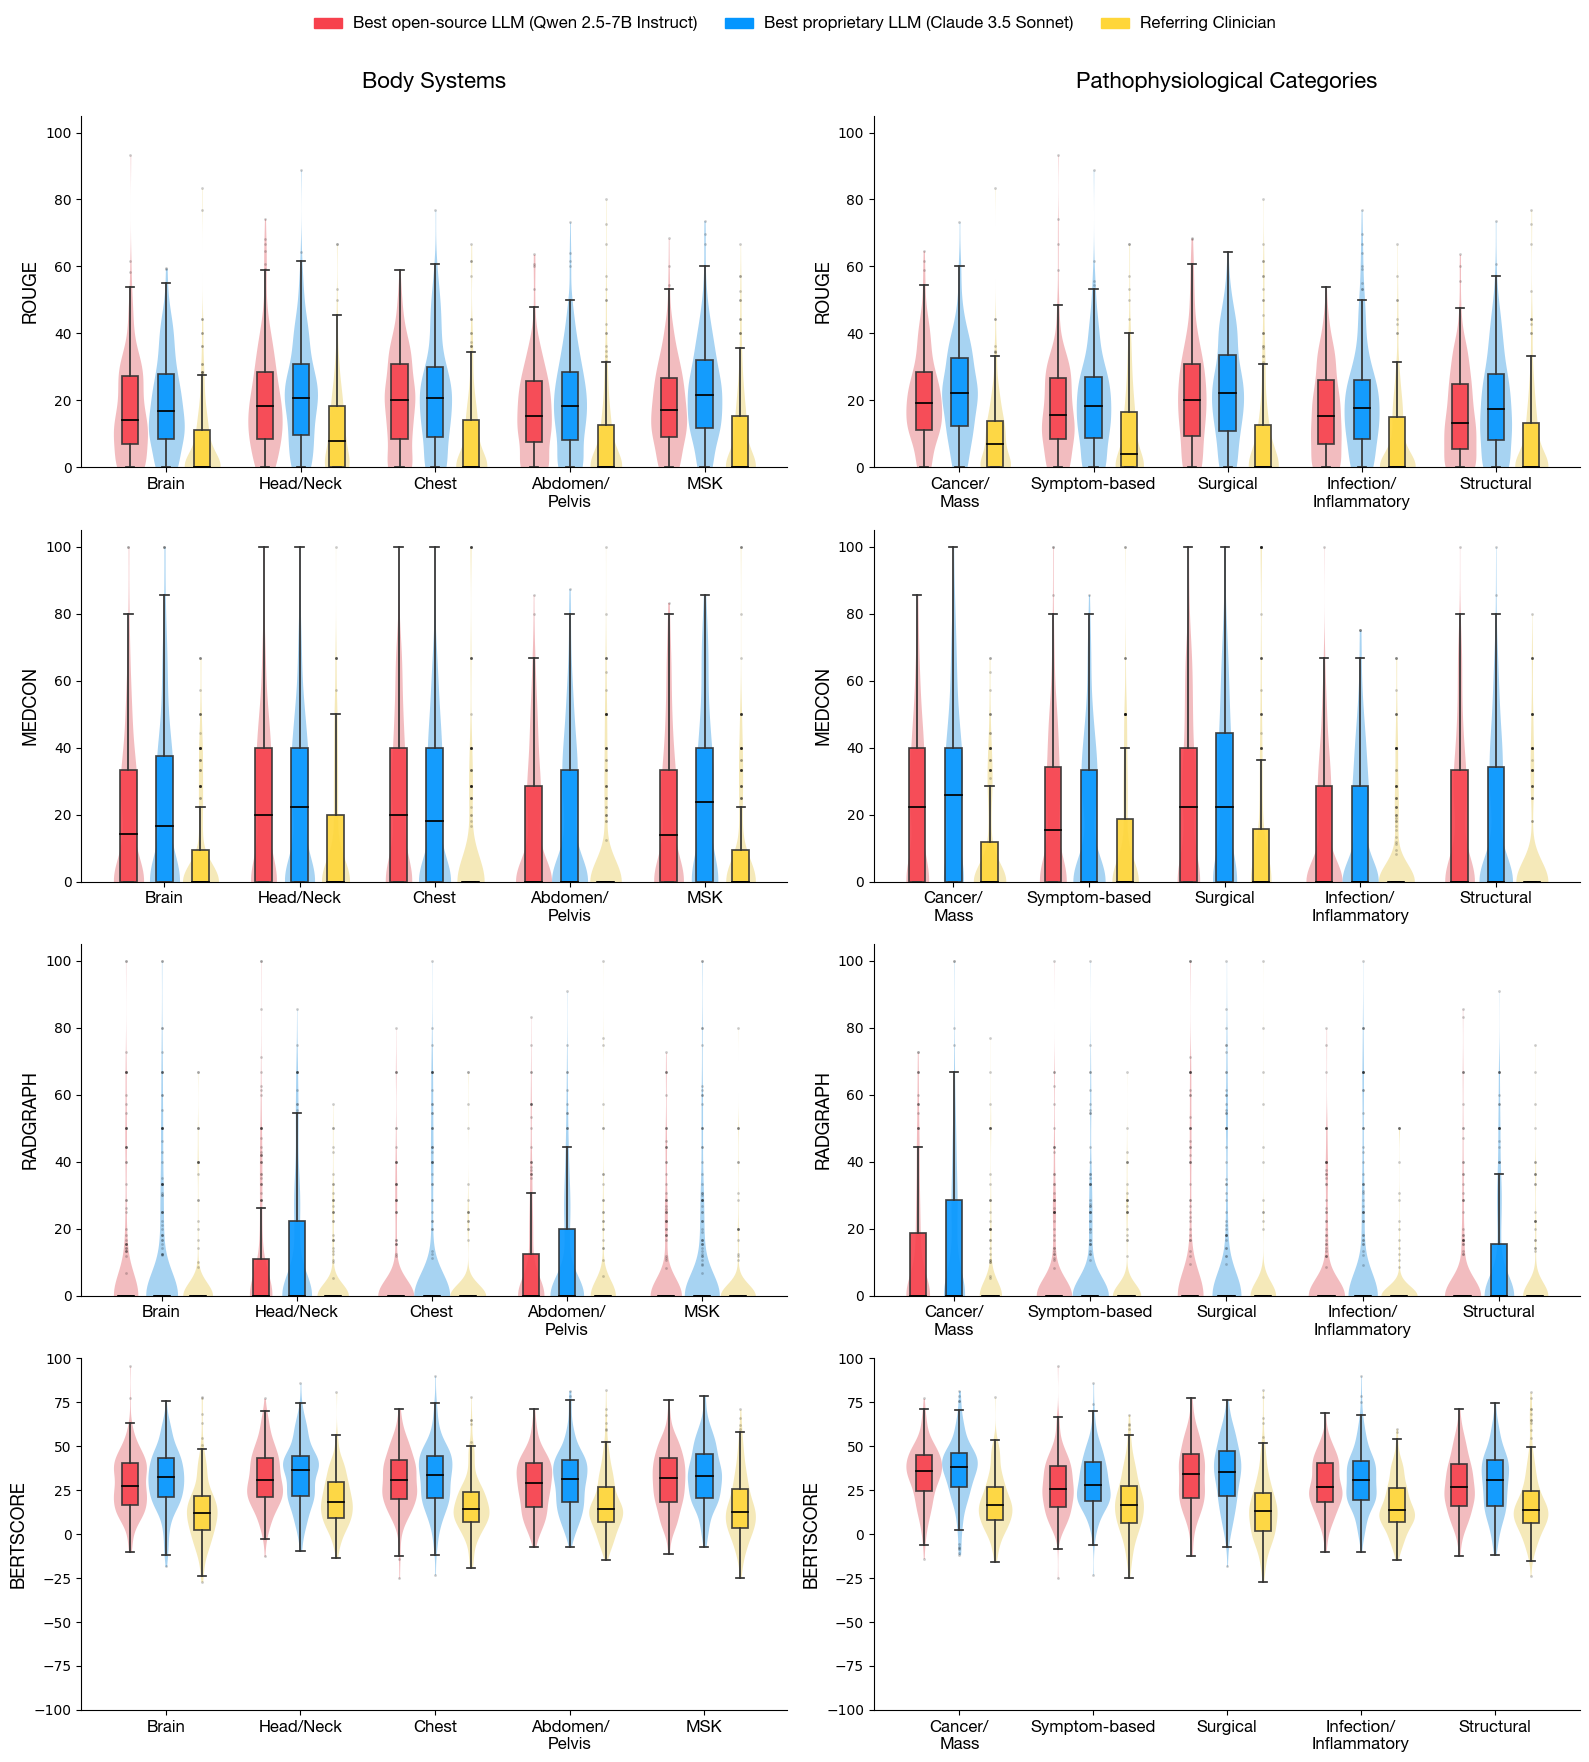

In [51]:
all_dfs = []
for m_key in MODELS:
    df = pd.read_csv(f"../analysis/llm_evaluation_scores/{m_key}.csv")
    df["Model"] = DISPLAY_NAMES[m_key]
    
    # Apply standard mappings
    if "body_system" in df.columns:
        df["body_system"] = df["body_system"].map(BODY_MAP).fillna(df["body_system"])
    if "pathophysiological_category" in df.columns:
        df["pathophysiological_category"] = df["pathophysiological_category"].map(PATHO_MAP).fillna(df["pathophysiological_category"])
    
    all_dfs.append(df)

fig4_data = pd.concat(all_dfs, ignore_index=True)

fig4_plot_data(fig4_data)

plt.savefig("figures/fig4_violin_box.png", dpi=300, bbox_inches='tight')
plt.show()

## Clinical Reader Study

### Dataset Curation

In [57]:
reader_study_results = pd.read_csv("final_llm_reader_study_results.csv")
reader_study_evaluation_dataset = pd.read_parquet("../dataset/randomized_reader_study_evaluation.parquet")

#### Case Assignment

In [58]:
#create small groupings, this is necessary for uniform distribution to ensure equal group sizing (in setting of a rectangular matrix...)
# we want 25 cases per person for 20 people  , 2 repeats of each case , so we want a dimension 10 matrix , 5 groupings of 3 and 5 groupings of 2
X = list()
for i in range(10):
    row = list()
    for j in range(10):
        if (j - i) % 10 in [0, 1, 2, 3, 4]:
            row.append(3)
        else:
            row.append(2)
    X.append(row)

# use X and our index array to create a matrix of the actual cases, grouped according to small groups defined in X - call this matrix Y.
# essentially we are sampling from the case index (labeled index) and drawing # of cases according to matrix X
# well its a "matrix" but really the structure is a list of lists. the first index will refer to the "row" and the second index will be the "column"
# Y will be a square matrix by construction

index = list(range(250))
Y = list()
start_index=0

for i in range(10):
    row = list()
    for j in range(10):
        row.append(index[start_index:start_index+X[i][j]])
        #update start_index
        start_index=start_index+X[i][j]
    Y.append(row)

# use matrix Y to create the final assignments by taking the union across each row to create the first set of 10 cases and then do the same by column for the second set of 10 cases store these as arrays
case_assignments=list()

#first assignment for first 10 raters, read along rows of Y
for i in range(10):
    case_assignments.append([element for row in Y[i] for element in row])

#second assignment for raters 11-20, read along columns of Y, create array of arrays to store reworked values. unfortunately list of lists makes this hard so create a temporary matrix Y2 first which is a transpose of Y
Y2= [Y[j][i] for i in range(10) for j in range(10)]

for i in range(10):
    case_assignments.append(([element for row in Y2[10*i:10*i+10] for element in row]))

#### Collating Reader Study Results 

In [59]:
all_rows = []

NUM_USERS = 20
for user_id in range(1, NUM_USERS + 1):
    eval_subset = reader_study_evaluation_dataset.iloc[case_assignments[user_id - 1]].reset_index(drop=True)
    results_subset = reader_study_results[reader_study_results["user_id"] == user_id].sort_values(by="set_id").reset_index(drop=True)

    for i in range(len(results_subset)):
        eval_row = eval_subset.iloc[i]
        result_row = results_subset.iloc[i]


        global_set_id = case_assignments[user_id - 1][i]
        category = eval_row.get("pathophysiological_category", np.nan)
        body_system = eval_row.get("body_system", np.nan)

        protocol_ranks = json.loads(result_row.get("protocol_usefulness_ranking", "{}"))
        interpretation_ranks = json.loads(result_row.get("interpretation_usefulness_ranking", "{}"))
        overall_ranks = json.loads(result_row.get("overall_ranking", "{}"))

        for n in range(1, 5):
            source = eval_row.get(f"indication{n}_choice", None)
            comp = result_row.get(f"indication_{n}_comprehensiveness", None)
            fact = result_row.get(f"indication_{n}_factuality", None)
            conc = result_row.get(f"indication_{n}_conciseness", None)
            indication_comment = result_row.get(f"indication_{n}_comment", None)

            note_texts = eval_row.get("note_texts", None)
            note_titles = eval_row.get("note_titles", None)
            indication_text = eval_row.get(source, None)
            general_comment = result_row.get("general_comment", None)
            
            indication_key = f"Indication {n}"
            protocol_rank = protocol_ranks.get(indication_key, None)
            interpretation_rank = interpretation_ranks.get(indication_key, None)
            overall_rank = overall_ranks.get(indication_key, None)

            factor_ranking_str = result_row.get("factor_ranking", None)
            try:
                factor_ranking_dict = json.loads(factor_ranking_str) if factor_ranking_str else {}
                sorted_factors = sorted(factor_ranking_dict, key=factor_ranking_dict.get)
                factor_ranking_1 = sorted_factors[0] if len(sorted_factors) > 0 else None
                factor_ranking_2 = sorted_factors[1] if len(sorted_factors) > 1 else None
                factor_ranking_3 = sorted_factors[2] if len(sorted_factors) > 2 else None
            except:
                factor_ranking_1 = factor_ranking_2 = factor_ranking_3 = None

            if source is not None:
                all_rows.append({
                    "user_id": user_id,
                    "global_set_id": global_set_id,
                    # "note_texts": note_texts,
                    # "note_titles": note_titles,
                    "indication_comment": indication_comment,
                    "general_comment": general_comment,
                    "pathophysiological_category": category,
                    "body_system": body_system,
                    "source": source,
                    "indication_text": indication_text,
                    "comprehensiveness": comp,
                    "factuality": fact,
                    "conciseness": conc,
                    "protocol_usefulness_rank": protocol_rank,
                    "interpretation_usefulness_rank": interpretation_rank,
                    "overall_rank": overall_rank,
                    "factor_ranking_1": factor_ranking_1,
                    "factor_ranking_2": factor_ranking_2,
                    "factor_ranking_3": factor_ranking_3,
                })

collated_reader_study_results = pd.DataFrame(all_rows)

#### Exclusion

In [60]:
excluded_set_ids = [29,73,105,122,141,143,152,166,184]
collated_reader_study_results = collated_reader_study_results[
    ~collated_reader_study_results["global_set_id"].isin(excluded_set_ids)
]

### Figure 5 (Constants)

In [131]:
FIGURE_5_MODELS = {
    "open_source": "llm_indication_qwen",
    "proprietary": "llm_indication_claude",
    "referring": "original_history",
    "radiologist": "additional_history"
}

FIGURE_5_DISPLAY_NAMES = {
    FIGURE_5_MODELS["open_source"]: 'Qwen 2.5-7B Instruct',
    FIGURE_5_MODELS["proprietary"]: 'Claude 3.5 Sonnet',
    FIGURE_5_MODELS["referring"]: 'Referring Clinician',
    FIGURE_5_MODELS["radiologist"]: "Radiologist"
}

FIGURE_5_MODEL_ORDER = [
    FIGURE_5_MODELS["referring"], 
    FIGURE_5_MODELS["radiologist"], 
    FIGURE_5_MODELS["open_source"], 
    FIGURE_5_MODELS["proprietary"]
]

LIKERT_FIELDS  = ["comprehensiveness", "factuality", "conciseness"]
SUBPLOT_TITLES = ["Comprehensiveness", "Factuality", "Conciseness"]
LIKERT_LEVELS  = [1, 2, 3, 4, 5]
COLORS_LIKERT = ['#F7414D', '#FF9AA2', '#d8d8d8', '#6EC5FF', '#0496FF']
VALUE_LABEL_THRESHOLD = 2.0 

SIG_BY_FIELD = {
    "comprehensiveness": [
        (FIGURE_5_MODELS["referring"],   FIGURE_5_MODELS["radiologist"], 1e-3),
        (FIGURE_5_MODELS["referring"],   FIGURE_5_MODELS["proprietary"], 1e-3),
        (FIGURE_5_MODELS["referring"],   FIGURE_5_MODELS["open_source"], 1e-3),
        (FIGURE_5_MODELS["radiologist"], FIGURE_5_MODELS["proprietary"], 1e-3),
        (FIGURE_5_MODELS["radiologist"], FIGURE_5_MODELS["open_source"], 1e-3),
        (FIGURE_5_MODELS["proprietary"], FIGURE_5_MODELS["open_source"], 0.011),
    ],
    "factuality": [
        (FIGURE_5_MODELS["referring"],   FIGURE_5_MODELS["radiologist"], 0.021),
        (FIGURE_5_MODELS["referring"],   FIGURE_5_MODELS["proprietary"], 1e-3),
        (FIGURE_5_MODELS["referring"],   FIGURE_5_MODELS["open_source"], 1e-3),
        (FIGURE_5_MODELS["radiologist"], FIGURE_5_MODELS["proprietary"], 1e-3),
        (FIGURE_5_MODELS["radiologist"], FIGURE_5_MODELS["open_source"], 0.191),
        (FIGURE_5_MODELS["proprietary"], FIGURE_5_MODELS["open_source"], 0.009),
    ],
    "conciseness": [
        (FIGURE_5_MODELS["referring"],   FIGURE_5_MODELS["radiologist"], 1e-3),
        (FIGURE_5_MODELS["referring"],   FIGURE_5_MODELS["proprietary"], 0.912),
        (FIGURE_5_MODELS["referring"],   FIGURE_5_MODELS["open_source"], 1e-3),
        (FIGURE_5_MODELS["radiologist"], FIGURE_5_MODELS["proprietary"], 1e-3),
        (FIGURE_5_MODELS["radiologist"], FIGURE_5_MODELS["open_source"], 0.288),
        (FIGURE_5_MODELS["proprietary"], FIGURE_5_MODELS["open_source"], 1e-3),
    ],
}

# Bracket Routing Math
TIER_MAP = {
    (0, 1): 0, (1, 2): 0, (2, 3): 0,  # Same column/level
    (0, 2): 1,                        # Next level out
    (1, 3): 2,                        # Next level out
    (0, 3): 3,                        # Outermost
}
BASE_INSET_BY_TIER = {0: 0.0, 1: 0.10, 2: 0.10, 3: 0.10}
ADJACENT_GAP = 0.3

### Figure 5 (Code)

In [136]:
def p_to_label(p):
    if p <= 1e-3:
        return "***"
    if p <= 1e-2:
        return "**"
    if p <= 5e-2:
        return "*"
    return "n.s."

def draw_sig_bracket(
    ax, y1, y2, text, tier, x_base, f_label,
    tier_step=8, tick=0.30, lw=1.6, text_pad=1.1
):
    x0 = x_base + tier * tier_step
    a, b = sorted((y1, y2))
    inset = BASE_INSET_BY_TIER.get(tier, 0.10)

    ylow, yhigh = a + inset, b - inset

    if b == a + 1:
        yhigh -= ADJACENT_GAP / 2.0
        ylow  += ADJACENT_GAP / 2.0

    ax.plot([x0, x0], [ylow, yhigh], color="black", linewidth=lw, zorder=5, clip_on=False)
    ax.plot([x0 - tick, x0], [ylow,  ylow],  color="black", linewidth=lw, zorder=5, clip_on=False)
    ax.plot([x0 - tick, x0], [yhigh, yhigh], color="black", linewidth=lw, zorder=5, clip_on=False)

    ax.text(
        x0 + tick + text_pad, (ylow + yhigh)/2,
        text, va="center", ha="left",
        fontproperties=f_label, zorder=5, clip_on=False
    )

def precompute_bracket_tiers():
    idx_of = {src: j for j, src in enumerate(FIGURE_5_MODEL_ORDER)}
    field_pairs = {}
    global_max = -1

    for field, rows in SIG_BY_FIELD.items():
        entries = []
        for a, b, p in rows:
            y1, y2 = sorted((idx_of[a], idx_of[b]))
            if (y1, y2) in TIER_MAP:
                tier = TIER_MAP[(y1, y2)]
                entries.append((y1, y2, p_to_label(p), tier))
                global_max = max(global_max, tier)
        field_pairs[field] = entries

    return field_pairs, global_max


def fig5_plot_data(df_main, font_path="fonts/HelveticaNeue.ttf"):

    f_title = fm.FontProperties(fname=font_path, size=18)
    f_axis  = fm.FontProperties(fname=font_path, size=16)
    f_label = fm.FontProperties(fname=font_path, size=14)

    fig, axes = plt.subplots(
        nrows=len(LIKERT_FIELDS),
        ncols=1,
        figsize=(15, 12),
        sharex=False
    )

    if len(LIKERT_FIELDS) == 1:
        axes = [axes]

    ytick_labels = [
        FIGURE_5_DISPLAY_NAMES.get(src, src)
        for src in FIGURE_5_MODEL_ORDER
    ]

    field_pairs, global_max_tier = precompute_bracket_tiers()

    BAR_RIGHT = 100.0
    gap = 0
    tier_step = 8
    label_buffer = 8.5
    BRACKET_GAP = 4.0

    for i, field in enumerate(LIKERT_FIELDS):
        ax = axes[i]

        df_group = (
            df_main.groupby(["source", field])
            .size()
            .unstack(fill_value=0)
            .reindex(columns=LIKERT_LEVELS, fill_value=0)
            .reindex(index=FIGURE_5_MODEL_ORDER, fill_value=0)
        )

        score_percents = (
            df_group.div(df_group.sum(axis=1).replace(0, np.nan), axis=0)
            .fillna(0) * 100
        )

        score_percents.plot(
            kind="barh",
            stacked=True,
            ax=ax,
            color=COLORS_LIKERT,
            width=0.7,
            legend=False
        )

        ax.set_ylabel("")
        ax.set_yticks(range(len(FIGURE_5_MODEL_ORDER)))
        ax.set_yticklabels(ytick_labels, fontproperties=f_axis)
        ax.get_xaxis().set_visible(False)
        ax.tick_params(axis='y', labelrotation=0, length=0, pad=10)

        for s in ax.spines.values():
            s.set_visible(False)

        for y_idx, row in enumerate(score_percents.values):
            x = 0.0
            for pct in row:
                if pct >= VALUE_LABEL_THRESHOLD:
                    ax.text(
                        x + pct/2.0,
                        y_idx,
                        f"{pct:.0f}%",
                        va="center",
                        ha="center",
                        fontproperties=f_label
                    )
                x += pct

        entries = field_pairs.get(field, [])
        if entries:
            extra = BRACKET_GAP + (global_max_tier + 1) * tier_step + label_buffer
            x_max = BAR_RIGHT + extra
            ax.set_xlim(0, x_max)

            x_base = BAR_RIGHT + BRACKET_GAP
            for y1, y2, lab, tier in entries:
                draw_sig_bracket(
                    ax, y1, y2, lab, tier,
                    x_base, f_label,
                    tier_step=tier_step
                )

            title_x = (BAR_RIGHT / 2.0) / x_max
            ax.set_title(
                SUBPLOT_TITLES[i],
                fontproperties=f_title,
                pad=15,
                x=title_x
            )
        else:
            ax.set_xlim(0, BAR_RIGHT)
            ax.set_title(
                SUBPLOT_TITLES[i],
                fontproperties=f_title,
                pad=15,
                x=0.5
            )

    likert_patches = []
    for c, lv in zip(COLORS_LIKERT, LIKERT_LEVELS):
        label = "1 (Lowest)" if lv == 1 else (
            "5 (Highest)" if lv == 5 else str(lv)
        )
        likert_patches.append(mpatches.Patch(color=c, label=label))

    fig.legend(
        handles=likert_patches,
        loc='upper center',
        ncol=5,
        frameon=False,
        prop=f_label,
        bbox_to_anchor=(0.5, 1.05)
    )

    fig.tight_layout(h_pad=4.0)
    return fig

### Figure 5 (Graphic)

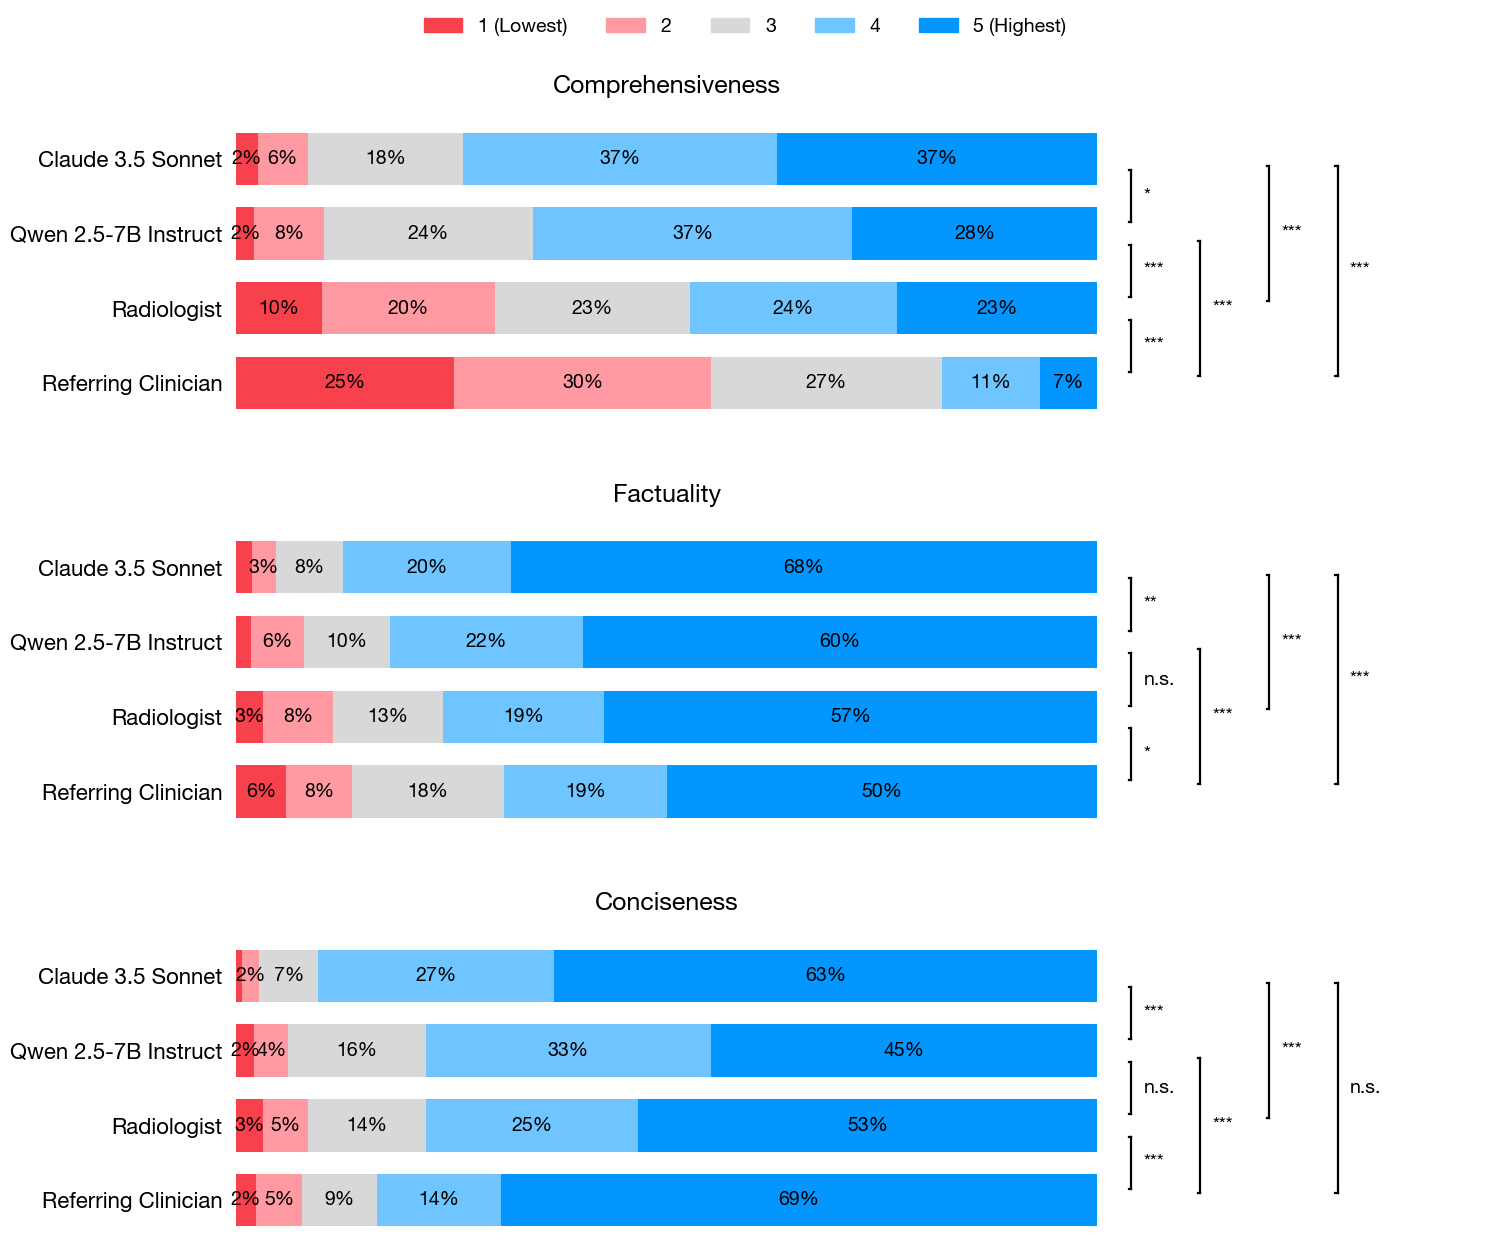

In [137]:
fig_5 = fig5_plot_data(collated_reader_study_results)
fig_5.savefig("figures/fig5_reader_study_likert_scores.png", dpi=300, bbox_inches="tight")
plt.show()

### Figure 6

/tmp/ipykernel_2102032/2156650862.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[LEFT_MARGIN, 0, 1, 0.97])


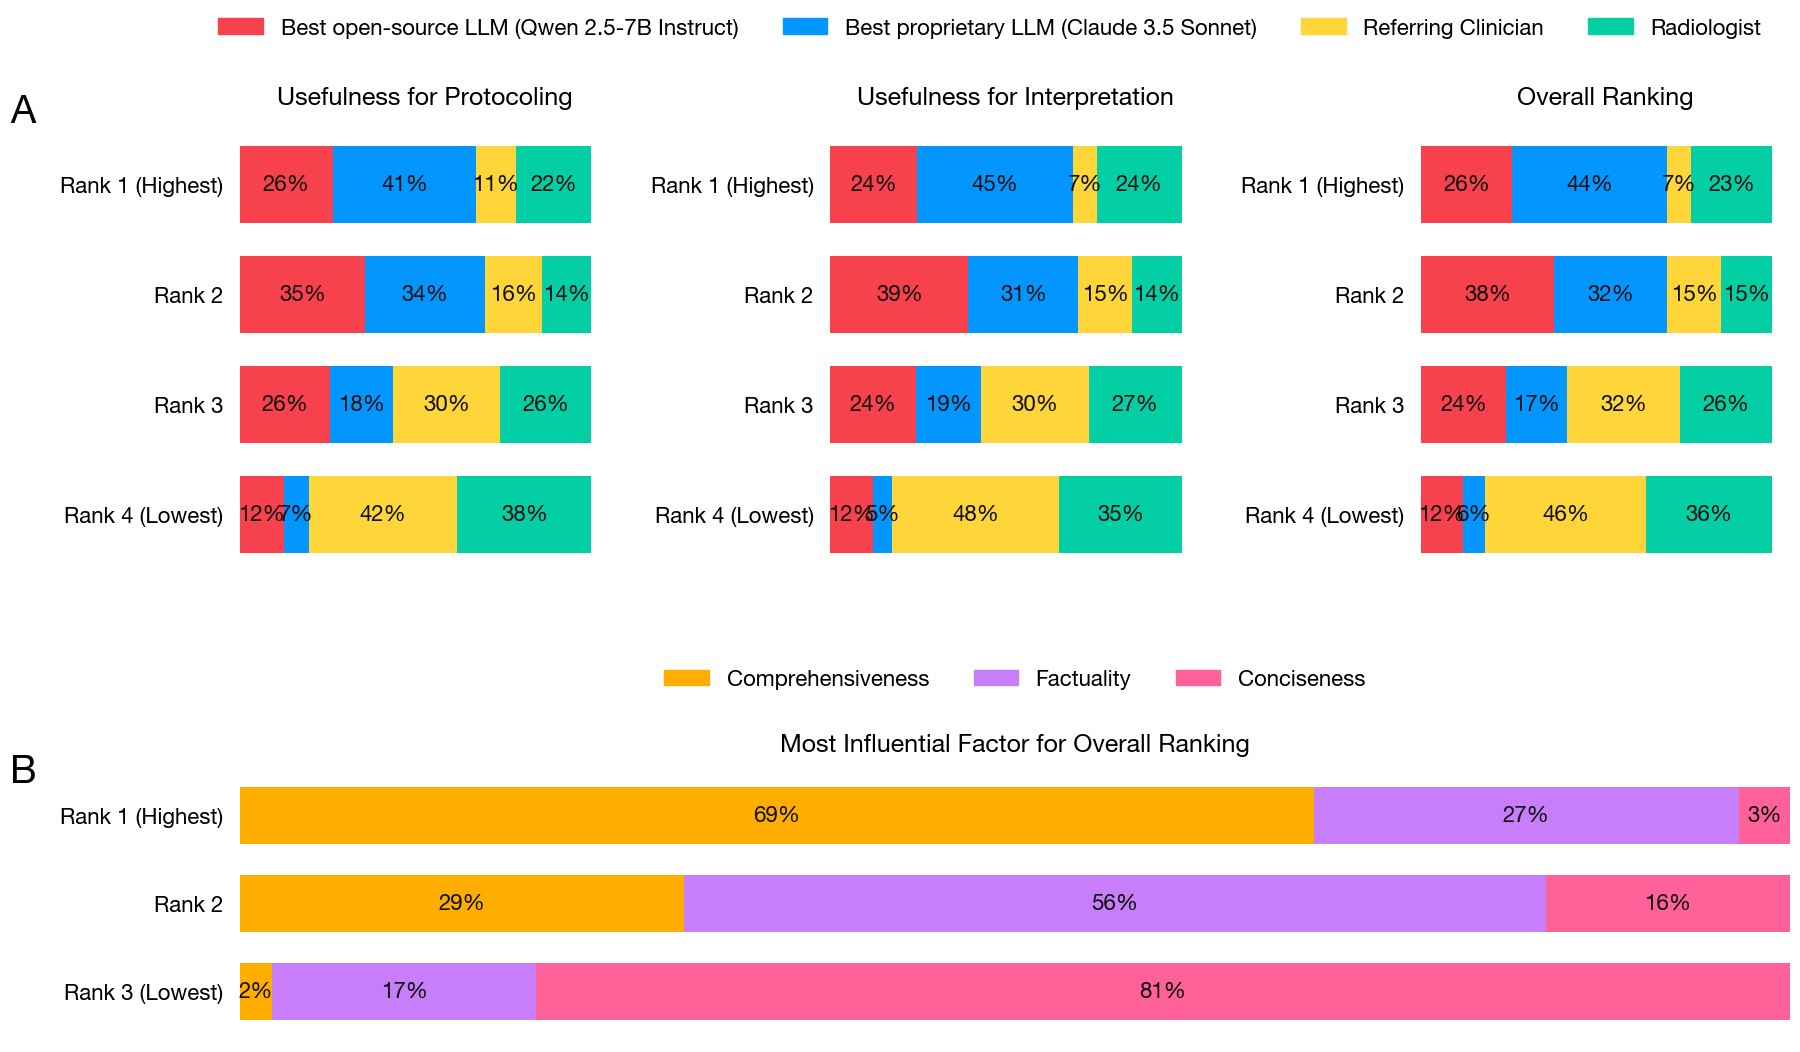

In [124]:
def rank_labels_from_index(index_like):
    r_int = [int(r) for r in list(index_like)]
    hi, lo = min(r_int), max(r_int)  # Rank 1 = Highest, Rank N = Lowest
    labels = []
    for r in r_int:
        if r == hi:
            labels.append(f"Rank {r} (Highest)")
        elif r == lo:
            labels.append(f"Rank {r} (Lowest)")
        else:
            labels.append(f"Rank {r}")
    return labels

model_order = [
    "llm_indication_qwen",
    "llm_indication_claude",
    "original_history",
    "additional_history",
]

DISPLAY_NAMES = {
    "llm_indication_qwen":   "Best open-source LLM (Qwen 2.5-7B Instruct)",
    "llm_indication_claude": "Best proprietary LLM (Claude 3.5 Sonnet)",
    "original_history":      "Referring Clinician",
    "additional_history":    "Radiologist",
}

COLOR_MAP_A = {
    "llm_indication_qwen": "#F7414D",
    "llm_indication_claude": "#0496FF",
    "original_history": "#FFD639",
    "additional_history": "#03CEA4",
}

COLOR_MAP_B = {
    "Comprehensiveness": "#FFAE00",
    "Factuality":        "#C87DFA",
    "Conciseness":       "#FF6198",
}

rank_fields = [
    "protocol_usefulness_rank",
    "interpretation_usefulness_rank",
    "overall_rank",
]
subplot_titles = [
    "Usefulness for Protocoling",
    "Usefulness for Interpretation",
    "Overall Ranking",
]

factor_rank_cols = ["factor_ranking_1", "factor_ranking_2", "factor_ranking_3"]
rank_titles = ["Rank 1 (Highest)", "Rank 2", "Rank 3 (Lowest)"]
rank_map = {
    "factor_ranking_1": "Rank 1 (Highest)",
    "factor_ranking_2": "Rank 2",
    "factor_ranking_3": "Rank 3 (Lowest)",
}

# -------------------------
# Fonts
# -------------------------
font_path = "fonts/HelveticaNeue.ttf"
F_TITLE = fm.FontProperties(fname=font_path, size=18)
F_TICK  = fm.FontProperties(fname=font_path, size=16)
F_LABEL = fm.FontProperties(fname=font_path, size=16)
F_LEG   = fm.FontProperties(fname=font_path, size=16)
F_PANEL = fm.FontProperties(fname=font_path, size=28, weight="bold")

FIGSIZE = (20, 12)
WS = 0.60
HS = 0.50
LABEL_PAD = 12
LEFT_MARGIN = 0.10  
SHOW_YLABELS_ON_ALL_TOP = True

fig = plt.figure(figsize=FIGSIZE)
outer = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[2.0, 1.2], hspace=HS)

top_gs = outer[0].subgridspec(nrows=1, ncols=3, wspace=WS)
axes_top = top_gs.subplots(sharey=False)
ax_bottom = fig.add_subplot(outer[1])

for i, (field, title) in enumerate(zip(rank_fields, subplot_titles)):
    ax = axes_top[i]

    # counts -> percents
    rank_counts = (
        collated_reader_study_results
        .groupby([field, "source"])
        .size()
        .unstack(fill_value=0)
    )
    rank_counts = rank_counts.sort_index()[::-1]
    rank_counts = rank_counts.reindex(columns=model_order, fill_value=0)

    if rank_counts.shape[0] == 0:
        ax.set_title(title, fontproperties=F_TITLE, pad=10)
        continue

    rank_percents = rank_counts.div(rank_counts.sum(axis=1), axis=0) * 100

    rank_percents.plot(
        kind="barh", stacked=True, ax=ax,
        color=[COLOR_MAP_A[m] for m in model_order],
        width=0.7, legend=False
    )

    ax.set_title(title, fontproperties=F_TITLE, pad=10)
    ax.set_xlabel("")
    ax.set_xticks([])
    ax.set_ylabel("")

    ax.tick_params(axis="y", length=0, pad=LABEL_PAD)
    ax.tick_params(axis="x", length=0)

    y_pos = np.arange(len(rank_counts.index))
    ax.set_yticks(y_pos)

    ylabels = rank_labels_from_index(rank_counts.index)

    if SHOW_YLABELS_ON_ALL_TOP:
        ax.set_yticklabels(ylabels, fontproperties=F_TICK)
        ax.tick_params(axis="y", labelleft=True)
    else:
        if i == 0:
            ax.set_yticklabels(ylabels, fontproperties=F_TICK)
            ax.tick_params(axis="y", labelleft=True)
        else:
            ax.tick_params(axis="y", labelleft=False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    for y_idx, row in enumerate(rank_percents.values):
        x_offset = 0.0
        for pct in row:
            if pct > 3:
                ax.text(
                    x_offset + pct / 2.0, y_idx,
                    f"{pct:.0f}%",
                    va="center", ha="center",
                    fontproperties=F_LABEL, color="#111"
                )
            x_offset += pct

unique_factors = collated_reader_study_results.drop_duplicates(subset=["global_set_id"])
df_long = unique_factors[factor_rank_cols].melt(var_name="rank_col", value_name="factor")
df_long["rank"] = df_long["rank_col"].map(rank_map)

rank_percents_factors = (
    df_long.groupby(["rank", "factor"]).size().unstack(fill_value=0)
    .reindex(columns=list(COLOR_MAP_B.keys()), fill_value=0)
)

row_sums = rank_percents_factors.sum(axis=1).replace(0, np.nan)
rank_percents_factors = (rank_percents_factors.div(row_sums, axis=0).fillna(0) * 100)
rank_percents_factors = rank_percents_factors.loc[rank_titles]

rank_percents_factors.plot(
    kind="barh", stacked=True, ax=ax_bottom,
    color=[COLOR_MAP_B[f] for f in rank_percents_factors.columns],
    width=0.65, legend=False
)

ax_bottom.set_title("Most Influential Factor for Overall Ranking", fontproperties=F_TITLE, pad=10)
ax_bottom.set_xlabel("")
ax_bottom.set_ylabel("")
ax_bottom.set_xlim(0, 100)
ax_bottom.set_xticks([])

ax_bottom.set_yticks(np.arange(len(rank_titles)))
ax_bottom.set_yticklabels(rank_titles, fontproperties=F_TICK)
ax_bottom.tick_params(axis="y", length=0, pad=LABEL_PAD)

for spine in ax_bottom.spines.values():
    spine.set_visible(False)

ax_bottom.invert_yaxis()

for y_idx, row in enumerate(rank_percents_factors.values):
    x_offset = 0.0
    for pct in row:
        if pct > 0:
            ax_bottom.text(
                x_offset + pct / 2.0, y_idx,
                f"{pct:.0f}%",
                va="center", ha="center",
                fontproperties=F_LABEL, color="#111"
            )
        x_offset += pct

legend_handles_models = [mpatches.Patch(color=COLOR_MAP_A[m], label=DISPLAY_NAMES[m]) for m in model_order]
fig.legend(
    handles=legend_handles_models,
    loc="upper center", ncol=4, frameon=False,
    prop=F_LEG, bbox_to_anchor=(0.5, 0.98)
)

legend_handles_factors = [mpatches.Patch(color=c, label=l) for l, c in COLOR_MAP_B.items()]
ax_bottom.legend(
    handles=legend_handles_factors,
    loc="lower center", bbox_to_anchor=(0.5, 1.2),
    ncol=3, frameon=False, prop=F_LEG
)

fig.text(0.01, 0.9, "A", fontproperties=F_PANEL, va="top", ha="left")
fig.text(0.01, 0.35, "B", fontproperties=F_PANEL, va="top", ha="left")

fig.tight_layout(rect=[LEFT_MARGIN, 0, 1, 0.97])
fig.savefig("figures/fig6_reader_study_rankings_plus_factors.png", dpi=300, bbox_inches="tight")